# Notebook 3: Model Comparison and Qualitative Analysis

This notebook compares the outputs of three pretrained NER tools applied to the same text segments extracted from *RG I*.

1. LatinCy
2. Multilingual Medieval RoBERTa
3. Multilingual XLM-R



In [30]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
sns.set_theme(style="whitegrid")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/digital_philology_rg1"
)

OUTPUT_DIR = PROJECT_DIR / "outputs"

FILES = {
    "input": OUTPUT_DIR / "rg1_ner_input.csv",
    "latincy": OUTPUT_DIR / "ner_latincy.csv",
    "medieval_roberta":
        OUTPUT_DIR / "ner_medieval_roberta.csv",
    "xlmr": OUTPUT_DIR / "ner_xlmr.csv",
}

missing = [
    str(path)
    for path in FILES.values()
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing files:\n" + "\n".join(missing)
    )

ner_input = pd.read_csv(
    FILES["input"],
    dtype={"lemma_id": str, "segment_id": str}
)

predictions = {
    name: pd.read_csv(
        path,
        dtype={"lemma_id": str, "segment_id": str}
    )
    for name, path in FILES.items()
    if name != "input"
}

print("All files loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All files loaded.


In [31]:
MODEL_NAMES = {
    "latincy": "LatinCy",
    "medieval_roberta": "Medieval RoBERTa",
    "xlmr": "Multilingual XLM-R",
}

LABEL_MAP = {
    "PER": "PERSON",
    "PERS": "PERSON",
    "PERSON": "PERSON",
    "LOC": "LOC",
    "LOCATION": "LOC",
    "ORG": "ORG",
    "NORP": "NORP",
}

combined = []

for model_key, df in predictions.items():
    df = df.copy()

    # Preserve the model's original information
    df["original_model"] = df["model"]

    if "original_label" not in df.columns:
        df["original_label"] = df["label"]

    # Add comparable model names and labels
    df["model"] = MODEL_NAMES[model_key]
    df["label"] = df["label"].replace(LABEL_MAP)

    # A lightly normalized entity string for later comparison
    df["entity_normalized"] = (
        df["entity"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.lower()
    )

    combined.append(df)

all_predictions = pd.concat(
    combined,
    ignore_index=True
)

print("Combined entity mentions:", len(all_predictions))

display(
    pd.crosstab(
        all_predictions["model"],
        all_predictions["label"]
    )
)

Combined entity mentions: 46225


label,LOC,NORP,ORG,PERSON
model,,,,
LatinCy,1075,110,0,15819
Medieval RoBERTa,2281,0,0,13891
Multilingual XLM-R,3103,0,525,9421


In [32]:
total_segments = ner_input["segment_id"].nunique()

total_words = (
    ner_input
    .drop_duplicates("segment_id")["word_count"]
    .sum()
)

model_summary = (
    all_predictions
    .groupby("model")
    .agg(
        entity_mentions=("entity", "size"),
        segments_with_entities=("segment_id", "nunique"),
        unique_entity_strings=("entity_normalized", "nunique"),
    )
)

model_summary["segment_coverage_pct"] = (
    model_summary["segments_with_entities"]
    / total_segments
    * 100
)

model_summary["mentions_per_1000_words"] = (
    model_summary["entity_mentions"]
    / total_words
    * 1000
)

label_counts = pd.crosstab(
    all_predictions["model"],
    all_predictions["label"]
).reindex(
    columns=["PERSON", "LOC", "ORG", "NORP"],
    fill_value=0
)

model_summary = (
    model_summary
    .join(label_counts)
    .reset_index()
)

model_summary = model_summary[
    [
        "model",
        "segments_with_entities",
        "segment_coverage_pct",
        "entity_mentions",
        "mentions_per_1000_words",
        "unique_entity_strings",
        "PERSON",
        "LOC",
        "ORG",
        "NORP",
    ]
]

display(
    model_summary.round({
        "segment_coverage_pct": 1,
        "mentions_per_1000_words": 1,
    })
)

,model,segments_with_entities,segment_coverage_pct,entity_mentions,mentions_per_1000_words,unique_entity_strings,PERSON,LOC,ORG,NORP
0,LatinCy,7811,82.8,17004,223.5,4337,15819,1075,0,110
1,Medieval RoBERTa,8015,85.0,16172,212.5,7602,13891,2281,0,0
2,Multilingual XLM-R,7843,83.1,13049,171.5,7429,9421,3103,525,0


In [33]:
from itertools import combinations

COMMON_LABELS = ["PERSON", "LOC"]
MATCH_COLUMNS = ["segment_id", "start", "end", "label"]

common_predictions = (
    all_predictions[
        all_predictions["label"].isin(COMMON_LABELS)
    ]
    .drop_duplicates(
        subset=["model"] + MATCH_COLUMNS
    )
)

model_sets = {
    model: set(
        map(
            tuple,
            df[MATCH_COLUMNS].itertuples(
                index=False,
                name=None
            )
        )
    )
    for model, df in common_predictions.groupby("model")
}

agreement_rows = []

for model_a, model_b in combinations(model_sets, 2):
    predictions_a = model_sets[model_a]
    predictions_b = model_sets[model_b]

    intersection = predictions_a & predictions_b
    union = predictions_a | predictions_b

    agreement_rows.append({
        "model_a": model_a,
        "model_b": model_b,
        "model_a_predictions": len(predictions_a),
        "model_b_predictions": len(predictions_b),
        "exact_matches": len(intersection),
        "jaccard_pct": len(intersection) / len(union) * 100,
    })

pairwise_exact_agreement = pd.DataFrame(agreement_rows)

display(
    pairwise_exact_agreement.round({
        "jaccard_pct": 1
    })
)

,model_a,model_b,model_a_predictions,model_b_predictions,exact_matches,jaccard_pct
0,LatinCy,Medieval RoBERTa,16894,16172,2670,8.8
1,LatinCy,Multilingual XLM-R,16894,12524,2064,7.5
2,Medieval RoBERTa,Multilingual XLM-R,16172,12524,5232,22.3


In [34]:
pairwise_exact_agreement["match_pct_of_a"] = (
    pairwise_exact_agreement["exact_matches"]
    / pairwise_exact_agreement["model_a_predictions"]
    * 100
)

pairwise_exact_agreement["match_pct_of_b"] = (
    pairwise_exact_agreement["exact_matches"]
    / pairwise_exact_agreement["model_b_predictions"]
    * 100
)

display(
    pairwise_exact_agreement.round({
        "jaccard_pct": 1,
        "match_pct_of_a": 1,
        "match_pct_of_b": 1,
    })
)

,model_a,model_b,model_a_predictions,model_b_predictions,exact_matches,jaccard_pct,match_pct_of_a,match_pct_of_b
0,LatinCy,Medieval RoBERTa,16894,16172,2670,8.8,15.8,16.5
1,LatinCy,Multilingual XLM-R,16894,12524,2064,7.5,12.2,16.5
2,Medieval RoBERTa,Multilingual XLM-R,16172,12524,5232,22.3,32.4,41.8


In [35]:
top_entities = (
    all_predictions
    .groupby(
        ["model", "entity_normalized", "label"]
    )
    .size()
    .reset_index(name="mentions")
    .sort_values(
        ["model", "mentions"],
        ascending=[True, False]
    )
    .groupby("model")
    .head(10)
)

for model in [
    "LatinCy",
    "Medieval RoBERTa",
    "Multilingual XLM-R",
]:
    print(f"\n{model}")

    model_top = (
        top_entities[top_entities["model"] == model]
        [["entity_normalized", "label", "mentions"]]
        .reset_index(drop=True)
    )

    model_top.index = model_top.index + 1
    display(model_top)


LatinCy


,entity_normalized,label,mentions
1,iohannes,PERSON,1090
2,traiect,PERSON,624
3,constant,PERSON,591
4,basil,PERSON,479
5,henricus,PERSON,345
6,meten,PERSON,328
7,iohannis,PERSON,320
8,petri,PERSON,286
9,ben,PERSON,265
10,colon,PERSON,251



Medieval RoBERTa


,entity_normalized,label,mentions
1,constant.,PERSON,686
2,meten.,PERSON,349
3,basil.,PERSON,329
4,colon.,PERSON,316
5,johannes de,PERSON,312
6,ben.,PERSON,242
7,magunt.,PERSON,198
8,argent.,PERSON,176
9,wratislav.,PERSON,126
10,magunt.,LOC,122



Multilingual XLM-R


,entity_normalized,label,mentions
1,basil.,PERSON,202
2,magunt.,LOC,195
3,meten.,LOC,153
4,magunt.,PERSON,140
5,leod.,PERSON,130
6,johannes,PERSON,125
7,constant.,LOC,108
8,wratislav.,PERSON,94
9,marie,PERSON,90
10,ben.,PERSON,88


In [36]:
# Separate the two section types
heads = (
    ner_input[ner_input["section"] == "head"]
    .drop_duplicates("segment_id")
)

sublemmata = (
    ner_input[ner_input["section"] == "sublemma"]
    .drop_duplicates("segment_id")
)

# Randomly select 10 from each section
sampled_heads = heads.sample(
    n=10,
    random_state=42
)

sampled_sublemmata = sublemmata.sample(
    n=10,
    random_state=45
)

# Combine the 20 selected segments
sampled_segments = pd.concat(
    [
        sampled_heads,
        sampled_sublemmata,
    ],
    ignore_index=True
)

sampled_segments["case_number"] = range(
    1,
    len(sampled_segments) + 1
)

sample_ids = sampled_segments["segment_id"].tolist()

display(
    sampled_segments[
        [
            "case_number",
            "segment_id",
            "section",
            "word_count",
            "abbreviation_count",
        ]
    ]
)

,case_number,segment_id,section,word_count,abbreviation_count
0,1,10101433-0,head,3,0
1,2,10103663-0,head,8,4
2,3,10101612-0,head,2,0
3,4,10102365-0,head,5,3
4,5,10102929-0,head,9,5
5,6,10103784-0,head,5,3
6,7,10100762-0,head,3,2
7,8,10102403-0,head,6,3
8,9,10101607-0,head,17,8
9,10,10100966-0,head,7,2


In [37]:
MODEL_ORDER = [
    "LatinCy",
    "Medieval RoBERTa",
    "Multilingual XLM-R",
]

sample_predictions = (
    all_predictions[
        all_predictions["segment_id"].isin(sample_ids)
    ]
    .sort_values(
        ["segment_id", "model", "start"]
    )
    .copy()
)

# Format each entity as: entity [LABEL]
sample_predictions["prediction"] = (
    sample_predictions["entity"].astype(str)
    + " ["
    + sample_predictions["label"].astype(str)
    + "]"
)

# Combine all entities predicted by the same model
formatted_predictions = (
    sample_predictions
    .groupby(
        ["segment_id", "model"]
    )["prediction"]
    .agg("; ".join)
    .reset_index()
)

# Create one column for each model
prediction_table = (
    formatted_predictions
    .pivot(
        index="segment_id",
        columns="model",
        values="prediction"
    )
    .reindex(columns=MODEL_ORDER)
    .reset_index()
    .rename_axis(columns=None)
)

print(
    "Entity mentions found in the selected sample:",
    len(sample_predictions)
)

Entity mentions found in the selected sample: 81


In [38]:
sample_columns = [
    "case_number",
    "lemma_id",
    "segment_id",
    "section",
    "word_count",
    "abbreviation_count",
    "ner_text",
]

sample_comparison = (
    sampled_segments[sample_columns]
    .merge(
        prediction_table,
        on="segment_id",
        how="left"
    )
    .fillna("No entity predicted")
    .sort_values("case_number")
)

display(sample_comparison)

,case_number,lemma_id,segment_id,section,word_count,abbreviation_count,ner_text,LatinCy,Medieval RoBERTa,Multilingual XLM-R
0,1,10101433,10101433-0,head,3,0,Hermannus de Oldendorf,Hermannus [PERSON],Hermannus de [PERSON]; Oldendorf [PERSON],Hermannus de Oldendorf [PERSON]
1,2,10103663,10103663-0,head,8,4,Waltherus Delictow can. eccl. in Rinvelden Basil. dioc.,Waltherus [PERSON]; Basil [PERSON],Waltherus Delictow [PERSON]; Rinvelden Basil. [LOC],Waltherus Delictow [PERSON]; Rinvelden Basil. [LOC]
2,3,10101612,10101612-0,head,2,0,Jacobus Reynwardi,Iacobus [PERSON]; Reynwardi [PERSON],Jacobus Reynwardi [PERSON],Jacobus Reynwardi [PERSON]
3,4,10102365,10102365-0,head,5,3,Johannes Roechli cler. Constant. dioc.,Iohannes [PERSON]; Roechli [PERSON]; Constant [PERSON],Johannes Roechli [PERSON]; Constant. [PERSON],Johannes Roechli [PERSON]
4,5,10102929,10102929-0,head,9,5,Nicolaus Pistoris can. eccl. s. Stephani Sarburgen. Meten. dioc.,Nicolaus Pistoris [PERSON]; Stephani [PERSON]; Sarburgen [PERSON]; Meten [PERSON],Nicolaus Pistoris [PERSON]; Stephani Sarburgen. [PERSON],Nicolaus Pistoris [PERSON]; Stephani Sarburgen. [PERSON]
5,6,10103784,10103784-0,head,5,3,Wilhelmus Mys cler. Colon. dioc.,Wilhelmus [PERSON]; Colon [PERSON],Wilhelmus Mys [PERSON]; Colon. [PERSON],Wilhelmus Mys [PERSON]
6,7,10100762,10100762-0,head,3,2,Fridericus. Constant. dioc.,Fridericus [PERSON]; Constant [PERSON],Fridericus. [PERSON]; Constant. [PERSON],Fridericus. [PERSON]
7,8,10102403,10102403-0,head,6,3,Johannes de Schellenberg can. eccl. August.,Iohannes [PERSON]; Schellenberg [PERSON]; August [PERSON],Johannes de [PERSON]; Schellenberg [PERSON],Johannes de Schellenberg [PERSON]; August. [PERSON]
8,9,10101607,10101607-0,head,17,8,Jacobus filius quondam Petri de Leyden presb. Traiect. dioc. perp. vicarius eccl. s. Petri Middelburgen. Traiect. dioc.,Iacobus [PERSON]; Petri [PERSON]; Leyden [PERSON]; Traiect [PERSON]; Petri [PERSON]; Middelburgen [LOC]; Traiect [PERSON],Jacobus [PERSON]; Petri de [PERSON]; Leyden [PERSON]; Petri Middelburgen. [PERSON],Jacobus [PERSON]; Petri de Leyden [PERSON]; Petri Middelburgen. [PERSON]
9,10,10100966,10100966-0,head,7,2,Guido Therrici cler. de Vandovillari Tullen. dioc.,Therrici [PERSON]; Uandouillari [PERSON]; Tullen [PERSON],Guido Therrici [PERSON]; Vandovillari Tullen. [LOC],Guido Therrici [PERSON]; Vandovillari [PERSON]


In [39]:
from IPython.display import display, Markdown

for _, row in sample_comparison.iterrows():

    display(
        Markdown(
            f"### Case {row['case_number']}: "
            f"`{row['segment_id']}`"
        )
    )

    print(
        f"Section: {row['section']} | "
        f"Words: {row['word_count']} | "
        f"Abbreviations: {row['abbreviation_count']}"
    )

    display(
        Markdown(
            f"**Text:** {row['ner_text']}"
        )
    )

    case_predictions = pd.DataFrame({
        "Model": MODEL_ORDER,
        "Predicted entities": [
            row[model]
            for model in MODEL_ORDER
        ],
    })

    display(case_predictions)

### Case 1: `10101433-0`

Section: head | Words: 3 | Abbreviations: 0


**Text:** Hermannus de Oldendorf

,Model,Predicted entities
0,LatinCy,Hermannus [PERSON]
1,Medieval RoBERTa,Hermannus de [PERSON]; Oldendorf [PERSON]
2,Multilingual XLM-R,Hermannus de Oldendorf [PERSON]


### Case 2: `10103663-0`

...

,Model,Predicted entities
0,LatinCy,No entity predicted
1,Medieval RoBERTa,Nanneten. [PERSON]
2,Multilingual XLM-R,Nanneten. [LOC]


### Case 20: `10103665-2`

Section: sublemma | Words: 11 | Abbreviations: 6


**Text:** m. prov. de can. eccl. s. Stephani Constant. 22 nov. 1378.

,Model,Predicted entities
0,LatinCy,Stephani [PERSON]
1,Medieval RoBERTa,Stephani Constant. [PERSON]
2,Multilingual XLM-R,Stephani [PERSON]; Constant. [LOC]


In [40]:
FIGURE_DIR = PROJECT_DIR / "figures"
FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_ORDER = [
    "LatinCy",
    "Medieval RoBERTa",
    "Multilingual XLM-R",
]

MODEL_COLORS = {
    "LatinCy": "#4C78A8",
    "Medieval RoBERTa": "#F58518",
    "Multilingual XLM-R": "#54A24B",
}

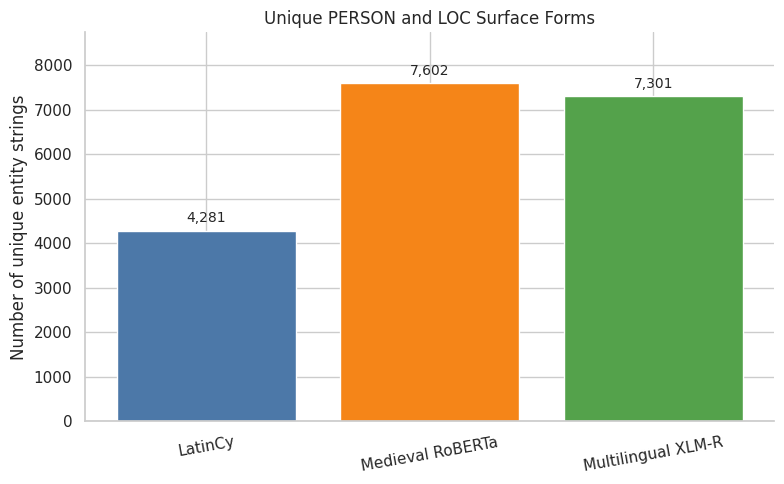

In [41]:
common_entity_forms = (
    all_predictions[
        all_predictions["label"].isin(
            ["PERSON", "LOC"]
        )
    ]
    .groupby("model")["entity_normalized"]
    .nunique()
    .reindex(MODEL_ORDER)
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

bars = ax.bar(
    common_entity_forms.index,
    common_entity_forms.values,
    color=[
        MODEL_COLORS[model]
        for model in common_entity_forms.index
    ]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:,}"
        for value in common_entity_forms.values
    ],
    padding=4,
    fontsize=10
)

ax.set_title(
    "Unique PERSON and LOC Surface Forms"
)

ax.set_ylabel(
    "Number of unique entity strings"
)

ax.set_xlabel("")

ax.set_ylim(
    0,
    common_entity_forms.max() * 1.15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=10)
plt.tight_layout()

fig.savefig(
    FIGURE_DIR / "unique_entity_surface_forms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

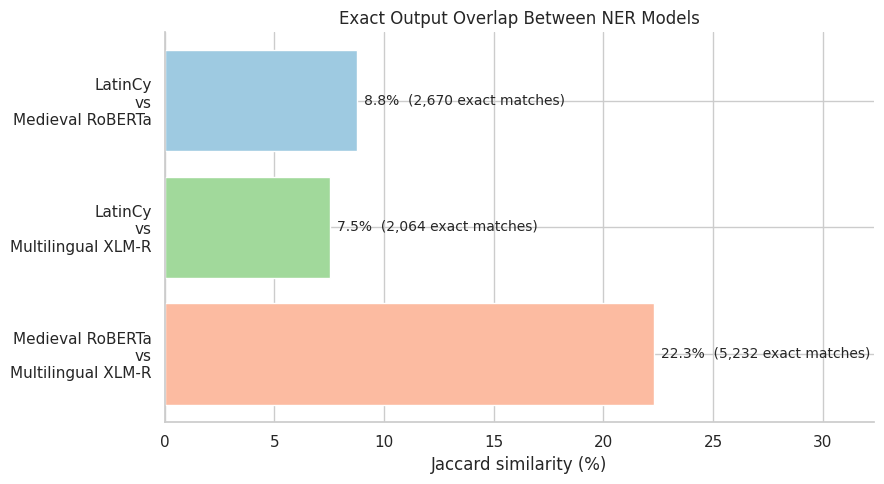

In [42]:
overlap_plot = (
    pairwise_exact_agreement
    .copy()
)

overlap_plot["model_pair"] = (
    overlap_plot["model_a"]
    + "\nvs\n"
    + overlap_plot["model_b"]
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.barh(
    overlap_plot["model_pair"],
    overlap_plot["jaccard_pct"],
    color=[
        "#9ECAE1",
        "#A1D99B",
        "#FCBBA1",
    ]
)

ax.bar_label(
    bars,
    labels=[
        f"{percentage:.1f}%  "
        f"({matches:,} exact matches)"
        for percentage, matches in zip(
            overlap_plot["jaccard_pct"],
            overlap_plot["exact_matches"]
        )
    ],
    padding=5,
    fontsize=10
)

ax.set_title(
    "Exact Output Overlap Between NER Models"
)

ax.set_xlabel(
    "Jaccard similarity (%)"
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    overlap_plot["jaccard_pct"].max() * 1.45
)

ax.invert_yaxis()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    FIGURE_DIR / "exact_model_overlap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()